# XGBoost Time Series Forecasting
- Notebook by Adam Lang
- Date: 8-28-2026

## Dataset
- This is a kaggle dataset called [hourly energy consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)

## Types of Time Series Data
1. Random error -- no patterns
2. Exponential/Quadratic (curvilnear trends)
3. Increasing Linear Trend
4. Seasonal Patterns
5. Seasonal Pattern + Linear Growth

### Types of Analysis
- Descriptive: summarizes key features of a data set. It helps in understanding the underlying patterns, trends, and seasonal variations in the data.

- Explanatory: goal is to understand the relationships and causal effects within the data. It seeks to explain why certain patterns or trends occur by examining the underlying factors and correlations.

- Predictive: using historical data, statistical models, and machine learning algorithms to predict future trends and patterns.

- Prescriptive: gives recommendations and actions based on predictive insights. It suggests optimal decisions by evaluating different scenarios and their potential outcomes.
- [source](https://in.mathworks.com/discovery/time-series-analysis.html)


## Classifications of Time Series
- Univariate: Tracks a single data variable over time, such as hourly temperature.
- Multivariate: Tracks two or more related variables at once to see how they affect each other, like temperature and humidity combined.
- Discrete: Recorded at fixed, equal time intervals like daily closing stock prices.
- Continuous: Captured constantly or at very high frequencies, like live heart monitor signals.
- Stationary: Has a stable mean and variance over time with no predictable trends.
- Non-Stationary: Shows continuous changes like an upward growth trend or seasonal shifts

## Metrics vs. Events
- Metrics: Data collected automatically at regular, fixed time steps (e.g., CPU usage every 60 seconds).
- Events: Data recorded at irregular, random intervals whenever an action happens (e.g., a user logging into a site or a credit card swipe).

## Structural Components
- Trend: The long-term direction of the data, going up, down, or flat.
- Seasonality: Short-term repeating patterns that happen on fixed schedules like holidays.
- Cyclical Variations: Long-term up-and-down waves that do not have a fixed schedule, like business economic cycles.
- Irregular Noise: Random, unpredictable changes caused by unexpected events
- [source](https://in.mathworks.com/discovery/time-series-analysis.html)

## Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
## set color palette
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

## model
import xgboost as xgb
from sklearn.metrics import mean_squared_error

## Load Dataset + EDA
- PJME_hourly.csv

In [2]:
## load data
df = pd.read_csv("/PJME_hourly.csv")
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [3]:
## tail
df.tail()

,Datetime,PJME_MW
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0
145365,2018-01-02 00:00:00,38608.0


In [4]:
## check dtypes
df.dtypes

,0
Datetime,object
PJME_MW,float64


Note:
- Need to cast as datetime object

In [5]:
## set index and cast as datetime
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [7]:
df_time = df.copy()

## Plot Time Series

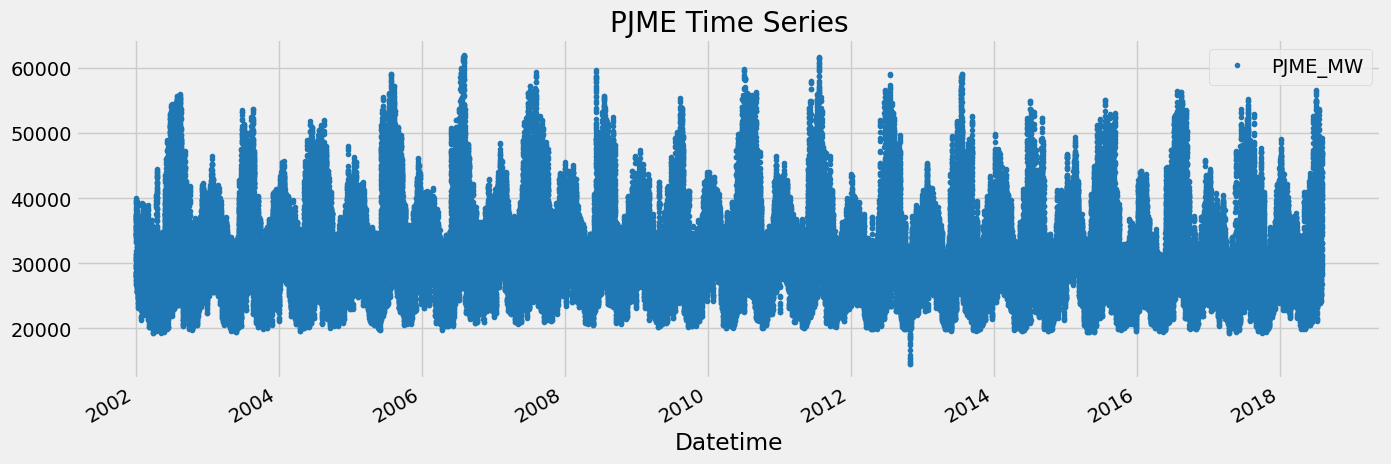

In [8]:
## plot time series
df_time.plot(style='.',
             figsize=(15,5),
             color=color_pal[0],
             title="PJME Time Series",
             ) # first color in color palette

plt.show();

# Train/Test Split
- we wont include cross validation here.
- we will train on everything prior to Jan 2015 and train on everything thereafter

In [9]:
## set on .loc index
train = df_time.loc[df_time.index < '01-01-2015']
test = df_time.loc[df_time.index >= '01-01-2015']


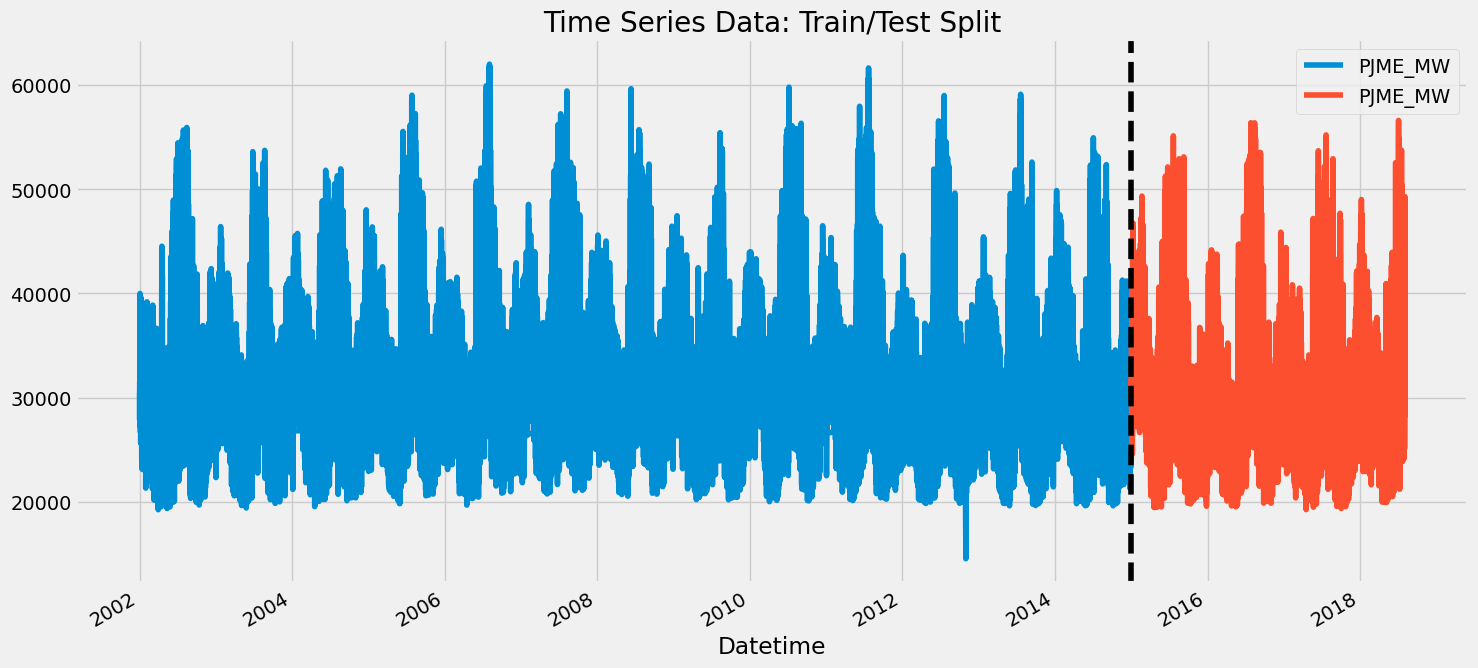

In [13]:
## plot both in same plot
fig, ax = plt.subplots(figsize=(16,8))
train.plot(ax=ax, label='Training Set')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--') ## line between train-test
plt.title("Time Series Data: Train/Test Split")
plt.show();

## View 1 week of Data

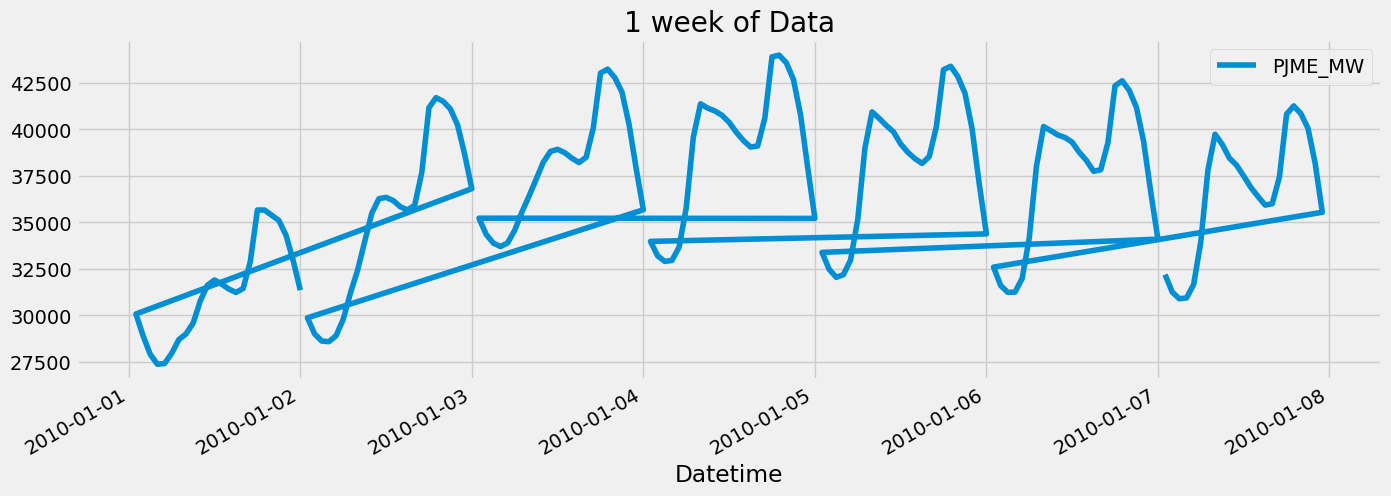

In [18]:
df_time.loc[(df_time.index > '01-01-2010') & (df_time.index < '01-08-2010')].plot(figsize=(15,5), title="1 week of Data")
plt.show();

## Feature Creation

In [26]:
## create individual time series features
def create_features(df):
  """
  Create time series features based on time series index.
  """
  df_time['hour'] = df_time.index.hour
  df_time['dayofweek'] = df_time.index.day_of_week
  df_time['quarter'] = df_time.index.quarter
  df_time['month'] = df_time.index.month
  df_time['year'] = df_time.index.year
  df_time['dayofyear'] = df_time.index.dayofyear

  return df

In [27]:
## create features with funciton
df_time = create_features(df_time)
df_time.head()

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear
Datetime,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,4,12,2002,365
2002-12-31 02:00:00,25147.0,2,1,4,12,2002,365
2002-12-31 03:00:00,24574.0,3,1,4,12,2002,365
2002-12-31 04:00:00,24393.0,4,1,4,12,2002,365
2002-12-31 05:00:00,24860.0,5,1,4,12,2002,365


## Visualize Feature/Target Relationship

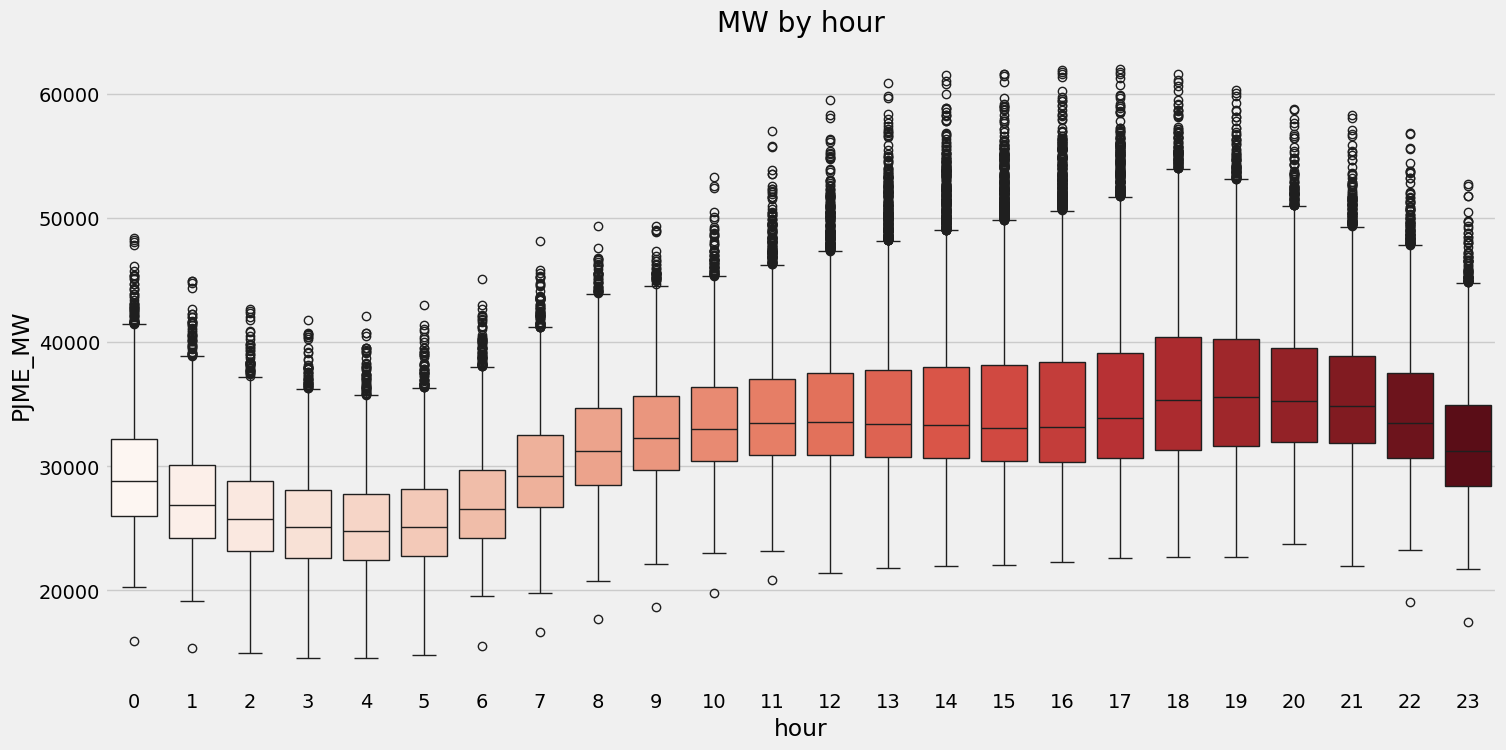

In [36]:
## boxplot - HOUR
fig, ax = plt.subplots(figsize=(16,8))
sns.boxplot(data=df_time, x='hour', y='PJME_MW',palette='Reds',hue='hour',legend=False)
ax.set_title("MW by hour")
plt.show();

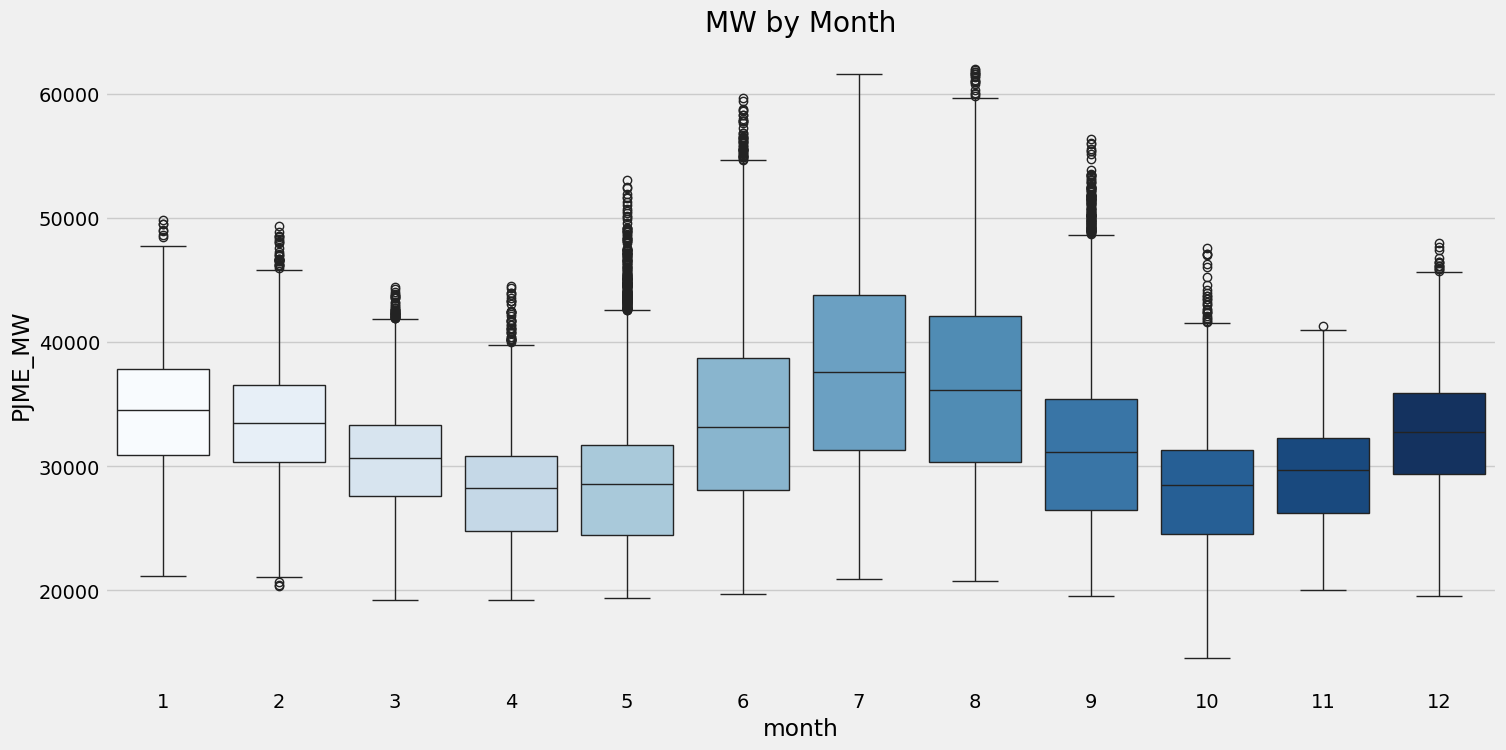

In [35]:
## boxplot - MONTH
fig, ax = plt.subplots(figsize=(16,8))
sns.boxplot(data=df_time, x='month', y='PJME_MW',hue='month', palette='Blues', legend=False)
ax.set_title("MW by Month")
plt.show();

## Feature creation on train and test set

In [47]:
## create individual time series features
def create_features(df):
  """
  Create time series features based on time series index.
  """
  ## first create copy
  df = df.copy()
  ## now create features
  df_time['hour'] = df_time.index.hour
  df_time['dayofweek'] = df_time.index.day_of_week
  df_time['quarter'] = df_time.index.quarter
  df_time['month'] = df_time.index.month
  df_time['year'] = df_time.index.year
  df_time['dayofyear'] = df_time.index.dayofyear

  return df

In [48]:
## create features on train/test
train = create_features(train)
test = create_features(test)

In [40]:
## check columns
df_time.columns

Index(['PJME_MW', 'hour', 'dayofweek', 'quarter', 'month', 'year',
       'dayofyear'],
      dtype='object')

In [53]:
train.columns

Index(['PJME_MW', 'hour', 'dayofweek', 'quarter', 'month', 'year',
       'dayofyear'],
      dtype='object')

In [44]:
## define features
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year','dayofyear']

## define prediction TARGET
TARGET = 'PJME_MW'

In [52]:
## create TRAIN features, target
# Ensure train has the features before selecting them
train['hour'] = train.index.hour
train['dayofweek'] = train.index.day_of_week
train['quarter'] = train.index.quarter
train['month'] = train.index.month
train['year'] = train.index.year
train['dayofyear'] = train.index.dayofyear
X_train = train[FEATURES]
y_train = train[TARGET] ## target

## create TEST features, target
# Ensure test has the features before selecting them
test['hour'] = test.index.hour
test['dayofweek'] = test.index.day_of_week
test['quarter'] = test.index.quarter
test['month'] = test.index.month
test['year'] = test.index.year
test['dayofyear'] = test.index.dayofyear
X_test = test[FEATURES]
y_test = test[TARGET]

## Build Model
- Regression instead of classification since we are predicting time series.

In [56]:
## xgboost regressor
reg_model = xgb.XGBRegressor(importance_type="gain",
                            n_estimators=1000,
                            max_depth=3,
                            early_stopping_rounds=50, # if test set does not improve
                            learning_rate=0.001,
                            random_state=42)
reg_model.fit(X_train, y_train,
              eval_set=[(X_train, y_train), (X_test, y_test)],
              verbose=100) ## print every 100 trees

[0]	validation_0-rmse:6449.49922	validation_1-rmse:6519.20171
[100]	validation_0-rmse:6191.57546	validation_1-rmse:6287.30287
[200]	validation_0-rmse:5961.69227	validation_1-rmse:6083.99262
[300]	validation_0-rmse:5737.36036	validation_1-rmse:5885.90688
[400]	validation_0-rmse:5532.60471	validation_1-rmse:5703.20566
[500]	validation_0-rmse:5345.68033	validation_1-rmse:5536.96960
[600]	validation_0-rmse:5179.05639	validation_1-rmse:5390.25166
[700]	validation_0-rmse:5001.67736	validation_1-rmse:5231.48908
[800]	validation_0-rmse:4863.51074	validation_1-rmse:5110.48498
[900]	validation_0-rmse:4745.13730	validation_1-rmse:5009.37283
[999]	validation_0-rmse:4641.65990	validation_1-rmse:4921.49961


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type='gain', interaction_constraints=None,
             learning_rate=0.001, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

## Feature Importance
- This is an advantage of using XGBoost.

In [59]:
fi = pd.DataFrame(data=reg_model.feature_importances_,
             index=reg_model.feature_names_in_,
             columns=['importance'])

In [60]:
fi

,importance
hour,0.325777
dayofweek,0.145421
quarter,0.000000
month,0.409595
year,0.007506
dayofyear,0.111701


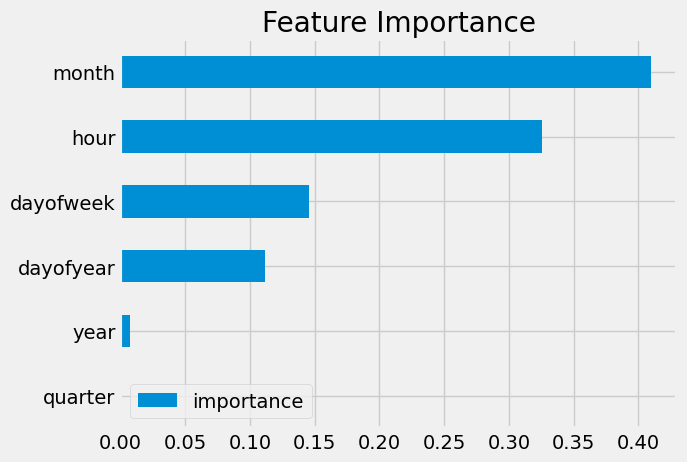

In [61]:
## plot fi's
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show();

## Summary
- We used 'gain' as the feature importance, but depending upon the type of feature importance we use it will weight and rank each differently as there are various ways to do this in XGBoost.

## Forecast on Test Set

In [62]:
## forecasting on test set
## create new column for predictions
test['prediction'] = reg_model.predict(X_test)

In [65]:
## merge on test set
df_time = df_time.merge(test[['prediction']], how='left', left_index=True, right_index=True)
df_time.head()

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,prediction
Datetime,,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,4,12,2002,365,NaN
2002-12-31 02:00:00,25147.0,2,1,4,12,2002,365,NaN
2002-12-31 03:00:00,24574.0,3,1,4,12,2002,365,NaN
2002-12-31 04:00:00,24393.0,4,1,4,12,2002,365,NaN
2002-12-31 05:00:00,24860.0,5,1,4,12,2002,365,NaN


## Plot Predictions

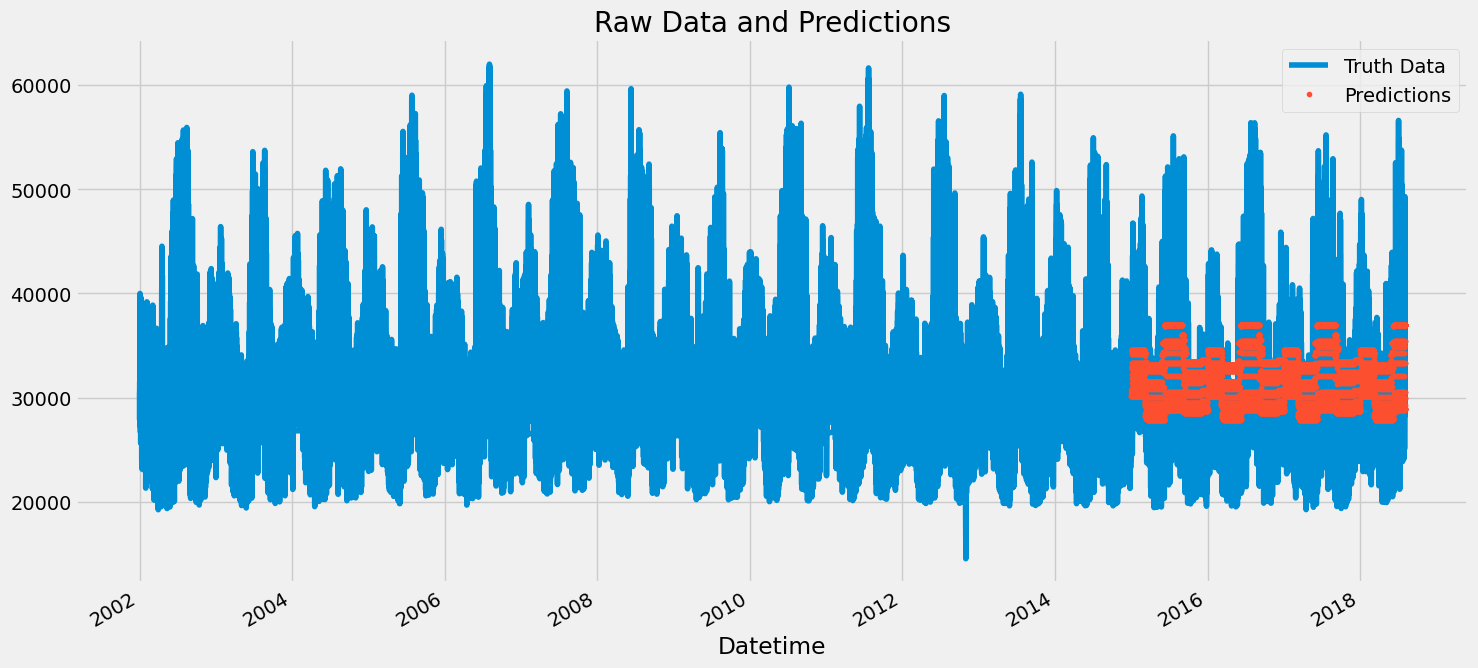

In [66]:
ax = df_time[['PJME_MW']].plot(figsize=(16,8))
df_time['prediction'].plot(ax=ax, style=".")
plt.legend(['Truth Data', 'Predictions'])
ax.set_title("Raw Data and Predictions")
plt.show();

## Summary
- We could absolutely improve this model by looking at various feature importance, hyperparameter tuning

# Evaluation

In [68]:
# eval metric
score = np.sqrt(mean_squared_error(test['PJME_MW'], test['prediction']))
score

np.float64(4921.499606106003)

## Calculate Error
- worst vs. best predicted days

In [70]:
test['error'] = np.abs(test[TARGET] - test['prediction'])

In [71]:
test['date'] = test.index.date

In [73]:
## worst predicted days
test.groupby('date')['error'].mean().sort_values(ascending=False).head()

,error
date,
2016-08-13,12556.635742
2016-08-14,11798.135742
2018-01-06,11626.098877
2016-08-12,11538.708496
2015-02-20,11449.037028


### Summary
- The worst predicted days all seem to be in mid August of 2016.

In [74]:
## best predicted days
test.groupby('date')['error'].mean().sort_values(ascending=True).head()

,error
date,
2017-03-18,926.625000
2016-12-29,1029.284180
2018-04-03,1056.669922
2017-07-06,1083.664551
2016-02-16,1102.643799


### Summary
- best predictions seem to be in March 2017 and December 2016.

# What is Next?
- To improve this you would want to:

1. Cross Validation -- more robust

2. Add more features (e.g. weather, holidays)

3. Take advantage of the feature_importance in XGBoost

4. Hyperparameter tuning
